In [40]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import importlib

import src.model as useModel
import src.utils as useUtils

importlib.reload(useModel)
importlib.reload(useUtils)

<module 'src.utils' from '/Users/Abhijeet/Desktop/Mac/Code/Personal Projects/Currently Working/Paper Implementation/exominer/src/utils.py'>

In [41]:
model = useModel.MultiBranchExoMiner(
    scalar_dim=16
)

print(model)

MultiBranchExoMiner(
  (full_flux_branch): TimeSeriesCNN(
    (features): Sequential(
      (0): ConvBlock(
        (block): Sequential(
          (0): Conv1d(1, 16, kernel_size=(5,), stride=(1,), padding=(2,))
          (1): PReLU(num_parameters=1)
          (2): Conv1d(16, 16, kernel_size=(5,), stride=(1,), padding=(2,))
          (3): PReLU(num_parameters=1)
          (4): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        )
      )
      (1): ConvBlock(
        (block): Sequential(
          (0): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(2,))
          (1): PReLU(num_parameters=1)
          (2): Conv1d(32, 32, kernel_size=(5,), stride=(1,), padding=(2,))
          (3): PReLU(num_parameters=1)
          (4): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        )
      )
      (2): ConvBlock(
        (block): Sequential(
          (0): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
          (1): 

In [31]:
full_flux = torch.randn(4,1,200) #4 batch size, 1 - one brightness signal, 200 measurements - fixed length signal but kepler doesnt contain fixed length

transit_flux = torch.randn(4,1,200)

full_centroid = torch.randn(4,1,200)

transit_centroid = torch.randn(4,1,200)

scalar_features = torch.randn(4,16)

output = model(
    full_flux,
    transit_flux,
    full_centroid,
    transit_centroid,
    scalar_features
)

print(output.shape)

torch.Size([4, 1])


In [32]:
sum(
    p.numel()
    for p in model.parameters()
)

7127005

In [ ]:
# Raw light curve
# ↓
# #Phase fold
# ↓
# #Resample
# ↓
# #Fixed-length vector

# creates a fixed size.

# 4096 → 1024 → 256 → 1

# 2048 → 512 → 128 → 1

# 1024 → 256 → 64 → 1

#Experiment, verify AUC-ROC, PR-AUC, Recall, choose best hidden_dim. Depends on info capacity needed and computational cost

# Model A:
# 6528 → 512 → 128 → 1

# Model B:
# 6528 → 1024 → 256 → 1

# Model C:
# 6528 → 256 → 64 → 1

# TimeSeriesCNN
# Input
# (1,200)

# ↓ Block1

# (16,100)

# ↓ Block2

# (32,50)

# ↓ Block3

# (64,25)

# ↓ Flatten

# 64×25 = 1600

In [5]:
N=100

In [9]:
#flux
full_flux = np.random.randn(
    N,
    1,
    200
)
transit_flux = np.random.randn(
    N,
    1,
    200
)

In [11]:
#centroids
full_centroid = np.random.randn(
    N,
    1,
    200
)
transit_centroid = np.random.randn(
    N,
    1,
    200
)

In [12]:
scalar_features = np.random.randn(
    N,
    16
)

#labels
labels = np.random.randint(
    0,
    2,
    size=N
)

## Creating dataset

In [13]:
from src.dataset import ExoMinerDataset

dataset = ExoMinerDataset(
    full_flux,
    transit_flux,
    full_centroid,
    transit_centroid,
    scalar_features,
    labels
)

In [14]:
sample = dataset[0]
for key, value in sample.items():
    print(
        key,
        value.shape if hasattr(value, "shape")
        else value
    )

full_flux torch.Size([1, 200])
transit_flux torch.Size([1, 200])
full_centroid torch.Size([1, 200])
transit_centroid torch.Size([1, 200])
scalar_features torch.Size([16])
label torch.Size([])


In [54]:
#DataLoader

from torch.utils.data import DataLoader
loader = DataLoader(
    dataset,
    batch_size=8,
    shuffle=True
)

In [55]:
batch = next(iter(loader))

In [56]:
batch["full_flux"].shape

torch.Size([8, 1, 200])

In [ ]:
# DataLoader automatically stacks multiple samples together
# along a new dimension (dimension 0).

In [57]:
#verify new timeseries cnn with multiple channels

cnn = useModel.TimeSeriesCNN(
    channels = [16,32,64]
)
useUtils.get_output_dim(cnn)

1600

In [58]:
batch = next(iter(loader))

for key, value in batch.items():
    print(key, value.shape)

full_flux torch.Size([8, 1, 200])
transit_flux torch.Size([8, 1, 200])
full_centroid torch.Size([8, 1, 200])
transit_centroid torch.Size([8, 1, 200])
scalar_features torch.Size([8, 16])
label torch.Size([8])


In [59]:
outputs = model(
    batch["full_flux"],
    batch["transit_flux"],
    batch["full_centroid"],
    batch["transit_centroid"],
    batch["scalar_features"]
)

print(outputs.shape)

torch.Size([8, 1])


In [44]:
print(type(model))

<class 'src.model.MultiBranchExoMiner'>


In [60]:
criterion = torch.nn.BCEWithLogitsLoss() #Doing binary=> planets=1,not planet=0 Sigmoid + BCE

In [61]:
optimizer = torch.optim.AdamW(
    model.parameters(), #every trainable weights get collected
    lr=1e-3
)

In [62]:
batch = next(iter(loader)) #grab one batch

In [63]:
for k, v in batch.items(): #inspecting shapes
    print(k,v.shape) #labels are [8], needed [8,1] so unsqueeze

full_flux torch.Size([8, 1, 200])
transit_flux torch.Size([8, 1, 200])
full_centroid torch.Size([8, 1, 200])
transit_centroid torch.Size([8, 1, 200])
scalar_features torch.Size([8, 16])
label torch.Size([8])


In [72]:
outputs = model( #frwd pass
    batch["full_flux"],
    batch["transit_flux"],
    batch["full_centroid"],
    batch["transit_centroid"],
    batch["scalar_features"]
)

In [73]:
print(outputs.shape)

torch.Size([8, 1])


In [74]:
#labels are [8], needed [8,1] so unsqueeze
labels = (
    batch["label"]
    .float()
    .unsqueeze(1)
)

In [75]:
#compute loss
loss = criterion(
    outputs,
    labels
)

In [76]:
print(loss.item()) #how wrong is model, smaller better

0.6884191036224365


In [77]:
#Backprop
optimizer.zero_grad()

loss.backward()

In [78]:
print(
    model.classifier[0].weight.grad.abs().mean()
)

tensor(1.3619e-05)


In [79]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total: {total_params:,}")
print(f"Trainable: {trainable_params:,}")

Total: 7,127,005
Trainable: 7,127,005


In [80]:
from src.train import train_one_epoch

In [81]:
import torch
import torch.nn as nn

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

model = MultiBranchExoMiner(
    scalar_dim=16
).to(device)

criterion = (
    nn.BCEWithLogitsLoss()
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3
)

In [82]:
loss = train_one_epoch(
    model,
    loader,
    optimizer,
    criterion,
    device
)

print(loss)

100%|███████████████████████████████████████████| 13/13 [00:00<00:00, 13.86it/s]

0.7302199006080627


In [83]:
for epoch in range(5):

    loss = train_one_epoch(
        model,
        loader,
        optimizer,
        criterion,
        device
    )

    print(
        f"Epoch {epoch}: "
        f"{loss:.4f}"
    )

100%|███████████████████████████████████████████| 13/13 [00:00<00:00, 17.02it/s]


Epoch 0: 0.7126


100%|███████████████████████████████████████████| 13/13 [00:00<00:00, 21.04it/s]


Epoch 1: 0.6927


100%|███████████████████████████████████████████| 13/13 [00:00<00:00, 23.22it/s]


Epoch 2: 0.6877


100%|███████████████████████████████████████████| 13/13 [00:00<00:00, 24.75it/s]


Epoch 3: 0.6526


100%|███████████████████████████████████████████| 13/13 [00:00<00:00, 23.73it/s]

Epoch 4: 0.6031


In [84]:
model.classifier[0].weight.grad.abs().mean()

tensor(2.9723e-05)

In [85]:
from src.train import train_one_epoch

In [86]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

model = MultiBranchExoMiner(
    scalar_dim=16
).to(device)

criterion = (
    nn.BCEWithLogitsLoss()
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3
)

for epoch in range(5):

    loss = train_one_epoch(
        model,
        loader,
        optimizer,
        criterion,
        device
    )

    print(
        f"Epoch {epoch}: "
        f"{loss:.4f}"
    )

100%|███████████████████████████████████████████| 13/13 [00:00<00:00, 17.52it/s]


Epoch 0: 0.7327


100%|███████████████████████████████████████████| 13/13 [00:00<00:00, 25.59it/s]


Epoch 1: 0.7044


100%|███████████████████████████████████████████| 13/13 [00:00<00:00, 27.76it/s]


Epoch 2: 0.6503


100%|███████████████████████████████████████████| 13/13 [00:00<00:00, 28.73it/s]


Epoch 3: 0.6203


100%|███████████████████████████████████████████| 13/13 [00:00<00:00, 20.09it/s]

Epoch 4: 0.6346


In [87]:
probs = torch.sigmoid(outputs)

In [88]:
preds = (probs > 0.5).float()

In [89]:
preds

tensor([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.]])

In [90]:
from src.evaluate import evaluate

In [91]:
for epoch in range(5):

    loss = train_one_epoch(
        model,
        loader,
        optimizer,
        criterion,
        device
    )

    acc = evaluate(
        model,
        loader,
        device
    )

    print(
        f"Epoch {epoch}"
    )

    print(
        f"Loss: {loss:.4f}"
    )

    print(
        f"Acc: {acc:.4f}"
    )

100%|███████████████████████████████████████████| 13/13 [00:00<00:00, 15.19it/s]


Epoch 0
Loss: 0.5153
Acc: 0.8400


100%|███████████████████████████████████████████| 13/13 [00:00<00:00, 18.50it/s]


Epoch 1
Loss: 0.3927
Acc: 0.9900


100%|███████████████████████████████████████████| 13/13 [00:00<00:00, 24.37it/s]


Epoch 2
Loss: 0.1739
Acc: 0.9800


100%|███████████████████████████████████████████| 13/13 [00:00<00:00, 18.46it/s]


Epoch 3
Loss: 0.2019
Acc: 0.9400


100%|███████████████████████████████████████████| 13/13 [00:00<00:00, 26.16it/s]


Epoch 4
Loss: 0.1230
Acc: 0.9800


## Training

In [93]:
import src.train
importlib.reload(src.train)
from src.train import fit

fit(
    model=model,
    loader=loader,
    optimizer=optimizer,
    criterion=criterion,
    epochs=5,
    device=device
)

Training: 100%|█████████████████████████████████| 13/13 [00:00<00:00, 15.25it/s]


Epoch [1/5]
Train Loss: 0.0708
Saved Best Model
--------------------------------------------------


Training: 100%|█████████████████████████████████| 13/13 [00:00<00:00, 26.30it/s]


Epoch [2/5]
Train Loss: 0.0738
--------------------------------------------------


Training: 100%|█████████████████████████████████| 13/13 [00:00<00:00, 27.55it/s]


Epoch [3/5]
Train Loss: 0.0265
Saved Best Model
--------------------------------------------------


Training: 100%|█████████████████████████████████| 13/13 [00:00<00:00, 26.74it/s]


Epoch [4/5]
Train Loss: 0.0205
Saved Best Model
--------------------------------------------------


Training: 100%|█████████████████████████████████| 13/13 [00:00<00:00, 27.07it/s]


Epoch [5/5]
Train Loss: 0.0012
Saved Best Model
--------------------------------------------------


Phasefolding

In [98]:
time = np.array([
    0,
    1,
    2,
    3,
    4,
    5,
    6
])

flux = np.array([
    1.0,
    1.0,
    0.98,
    1.0,
    1.0,
    0.99,
    1.0
])

period = 3

In [99]:
import src.preprocessing.phase_fold

importlib.reload(
    src.preprocessing.phase_fold
)
from src.preprocessing.phase_fold import phase_fold
phase, folded_flux = phase_fold(
    time,
    flux,
    period=3
)

print(phase)
print(folded_flux)

[0 0 0 1 1 2 2]
[1.   1.   1.   1.   1.   0.98 0.99]


In [100]:
from src.preprocessing.transit_centered_fold import (
    transit_centered_fold
)

time = np.arange(0, 20)

flux = np.ones_like(
    time,
    dtype=float
)

flux[5] = 0.98
flux[15] = 0.97

period = 10
epoch = 5

phase, folded_flux = transit_centered_fold(
    time,
    flux,
    period,
    epoch
)

print(phase[:10])
print(folded_flux[:10])

[-0.5 -0.5 -0.4 -0.4 -0.3 -0.3 -0.2 -0.2 -0.1 -0.1]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


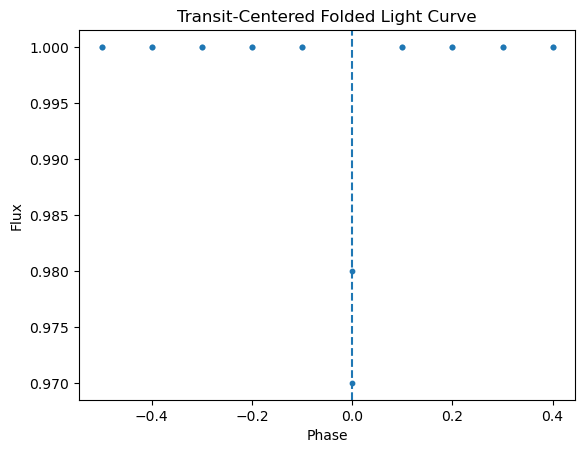

In [101]:
import matplotlib.pyplot as plt

plt.scatter(
    phase,
    folded_flux,
    s=10
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Phase")
plt.ylabel("Flux")
plt.title("Transit-Centered Folded Light Curve")

plt.show()